# Lab 12

By Niksh Hiremath (U20240158)

## 1. Code

### Importing libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import tensorflow as tf

np.random.seed(0)

### Loading dataset

In [12]:
data = np.genfromtxt("Fertility_Diagnosis.txt", delimiter=",")
print(f"Dataset shape: {data.shape}")

Dataset shape: (100, 10)


In [13]:
X = data[:, :9]
y = data[:, 9].reshape(-1, 1)

# Creating training and testing datasets (80-20 split)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 80
Test size: 20


### Defining network parameters

In [14]:
INPUT_SIZE = X_train.shape[1]
OUTPUT_SIZE = 1

ALPHA = 0.001
ERROR_TOLERANCE = 0.05
MAX_ITER = 1_000_001

train_errors = []
test_errors = []

### Sigmoid activation function

In [15]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))


def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

### Training loop over different hidden layer sizes

In [16]:
for n_hidden in range(1, 10):
    print(f"\nHidden neurons: {n_hidden}")

    W1 = np.random.randn(INPUT_SIZE, n_hidden)
    W2 = np.random.randn(n_hidden, OUTPUT_SIZE)

    for i in range(MAX_ITER):
        # Feedforward pass
        layer0 = X_train

        z1 = np.dot(layer0, W1)
        layer1 = sigmoid(z1)

        z2 = np.dot(layer1, W2)
        layer2 = sigmoid(z2)

        # Backpropagation
        cost = y_train - layer2

        delta2 = cost * sigmoid_derivative(z2)
        W2 += ALPHA * np.dot(layer1.T, delta2)

        delta1 = np.dot(delta2, W2.T) * sigmoid_derivative(z1)
        W1 += ALPHA * np.dot(layer0.T, delta1)

        mse = mean_squared_error(y_train, layer2)
        if mse < ERROR_TOLERANCE:
            print(f"Stopping at iteration {i} | MSE: {mse:.6f}")
            break

        if i % 100_000 == 0:
            print(f"\tIter {i:>7} | Train MSE: {mse:.6f}")

    z1_tr = np.dot(X_train, W1)
    l1_tr = sigmoid(z1_tr)
    z2_tr = np.dot(l1_tr, W2)
    l2_tr = sigmoid(z2_tr)
    train_mse = mean_squared_error(y_train, l2_tr)
    train_errors.append(train_mse)
    print(f"Train MSE (hidden={n_hidden}): {train_mse:.6f}")

    z1_te = np.dot(X_test, W1)
    l1_te = sigmoid(z1_te)
    z2_te = np.dot(l1_te, W2)
    l2_te = sigmoid(z2_te)
    test_mse = mean_squared_error(y_test, l2_te)
    test_errors.append(test_mse)
    print(f"Test MSE (hidden={n_hidden}): {test_mse:.6f}")


Hidden neurons: 1
	Iter       0 | Train MSE: 0.323856
	Iter  100000 | Train MSE: 0.098411
	Iter  200000 | Train MSE: 0.080655
	Iter  300000 | Train MSE: 0.078663
	Iter  400000 | Train MSE: 0.077610
	Iter  500000 | Train MSE: 0.076824
	Iter  600000 | Train MSE: 0.076142
	Iter  700000 | Train MSE: 0.075538
	Iter  800000 | Train MSE: 0.075009
	Iter  900000 | Train MSE: 0.074548
	Iter 1000000 | Train MSE: 0.074144
Train MSE (hidden=1): 0.074144
Test MSE (hidden=1): 0.099011

Hidden neurons: 2
	Iter       0 | Train MSE: 0.595336
	Iter  100000 | Train MSE: 0.081730
	Iter  200000 | Train MSE: 0.078353
	Iter  300000 | Train MSE: 0.076565
	Iter  400000 | Train MSE: 0.075330
	Iter  500000 | Train MSE: 0.074317
	Iter  600000 | Train MSE: 0.073326
	Iter  700000 | Train MSE: 0.070774
	Iter  800000 | Train MSE: 0.066988
	Iter  900000 | Train MSE: 0.065573
	Iter 1000000 | Train MSE: 0.064586
Train MSE (hidden=2): 0.064586
Test MSE (hidden=2): 0.079296

Hidden neurons: 3
	Iter       0 | Train MSE: 0.

### Plotting training and testing errors

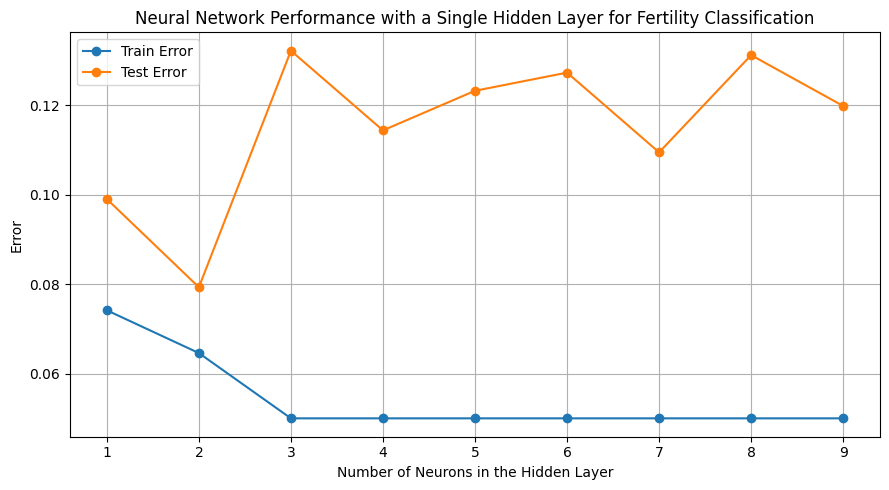

In [17]:
n_neurons = list(range(1, 10))

plt.figure(figsize=(9, 5))
plt.plot(n_neurons, train_errors, label="Train Error", marker="o")
plt.plot(n_neurons, test_errors, label="Test Error", marker="o")

plt.xlabel("Number of Neurons in the Hidden Layer")
plt.ylabel("Error")
plt.title(
    "Neural Network Performance with a Single Hidden Layer for Fertility Classification"
)
plt.xticks(n_neurons)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

**Best number of hidden neurons:** 2

## 2. Report

### Q1: What happens if all the weights are initialized to zero (zero initialization)?

**Ans:**

- If all weights are initialized to zero, every neuron in a layer computes the same output and receives the same gradient during backpropagation. 

- Hence all neurons in a hidden layer learn identical features.

---

### Q2: What is the difference between epoch, batch, and iteration in neural networks?

**Ans:**

- **Epoch:** One complete pass through the entire training dataset.

- **Batch:** A subset of the training data used in one forward and backward pass. Batch size determines how many samples are processed before a weight update.

- **Iteration:** One forward and backward pass using a single batch.

---

### Q3: What is the key difference between stochastic gradient descent and batch gradient descent?

**Ans:**

- **Stochastic Gradient Descent (SGD):** Uses a single randomly selected training sample per weight update. It is much faster and can escape local minima due to noisy updates, but the updates are highly variable and convergence is less stable.

- **Batch Gradient Descent (BGD):** Uses the entire training dataset to compute the gradient and update weights once per epoch. It gives a stable, accurate gradient but is slow for large datasets.

---

### Q4: What problems does a completely random initialization of a neural network lead to?

**Ans:**

- **Vanishing gradients:** If weights are initialized too small, activations shrink through layers and gradients become near zero, causing early layers to learn very slowly.

- **Exploding gradients:** If weights are initialized too large, activations and gradients grow exponentially through layers, causing unstable or divergent training.

- **Slow convergence:** Poor random initialization can place the network in a region of the loss landscape that is far from any good solution, requiring many more iterations to converge.

---

### Q5: Name any ten hyperparameters in a multi-layer neural network.

**Ans:**

1. Learning rate
2. Number of hidden layers
3. Number of neurons per hidden layer
4. Batch size
5. Number of epochs
6. Activation function
7. Optimizer
8. Momentum
9. Regularization parameters
10. Dropout rate

---